In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [4]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

Text(0.5, 0, 'wavelength')

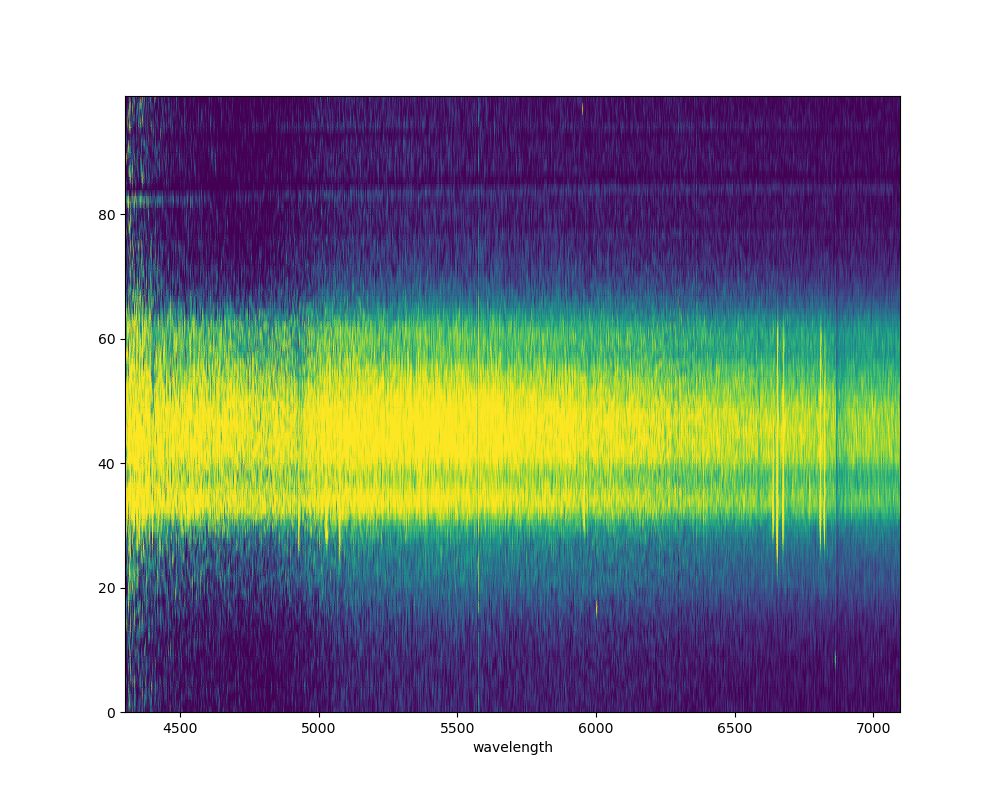

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.01505 
l_HA_z = 6563 * (1+z)
l_HB_z = 4861 * (1+z) 
l_NII_z = 6583 * (1+z)
l_SII_z = 6717 * (1+z)
l_OIII_z = 5007 * (1+z)

l_HA = 6654
l_HB = 4929 
l_NII = 6676
l_SII = 6811
l_OIII = 5077

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/PSF/Real_seeing_Mrk553.txt")
sigmas = seeing / 2.35
n_component = 4
print(sigmas)

[1.33752352 1.52488205 1.33526917 1.32124473 1.50859987 1.3506383 ]


In [7]:
l_HA

6654

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

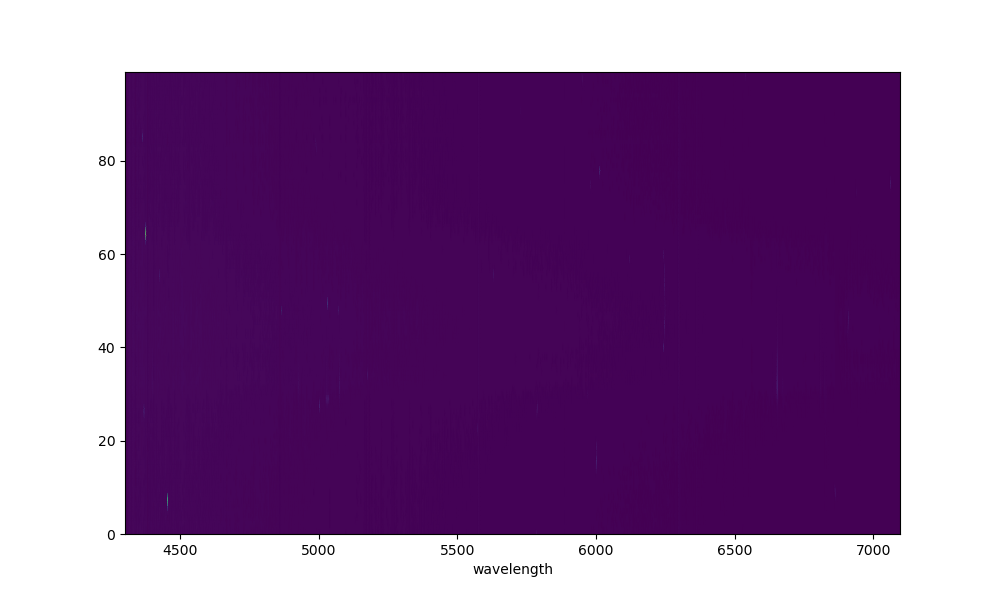

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[75:175, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

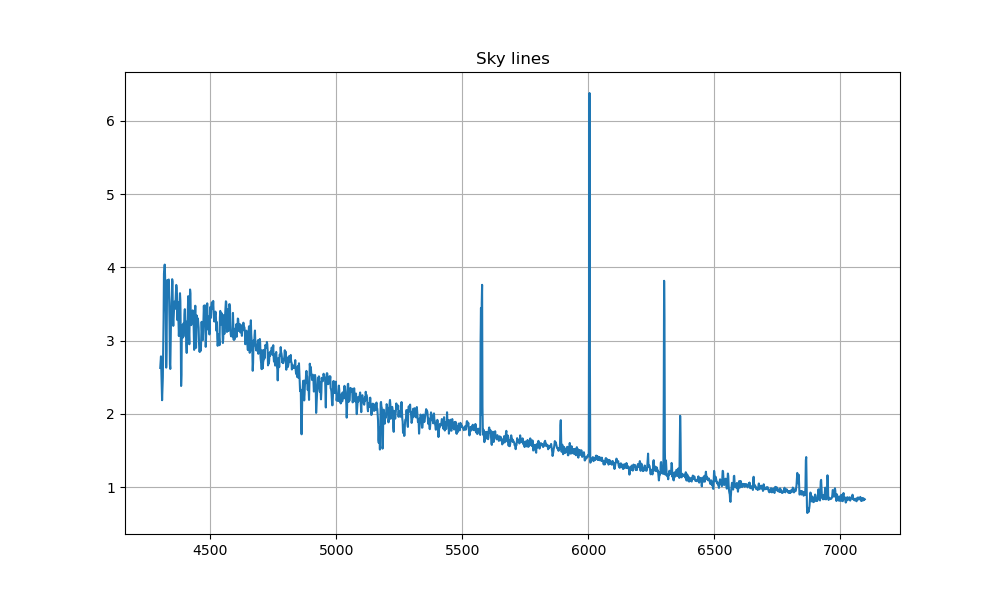

In [9]:
mask_sky = (y > 15)*(y < 25)
#mask_wv = wv > 4400
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

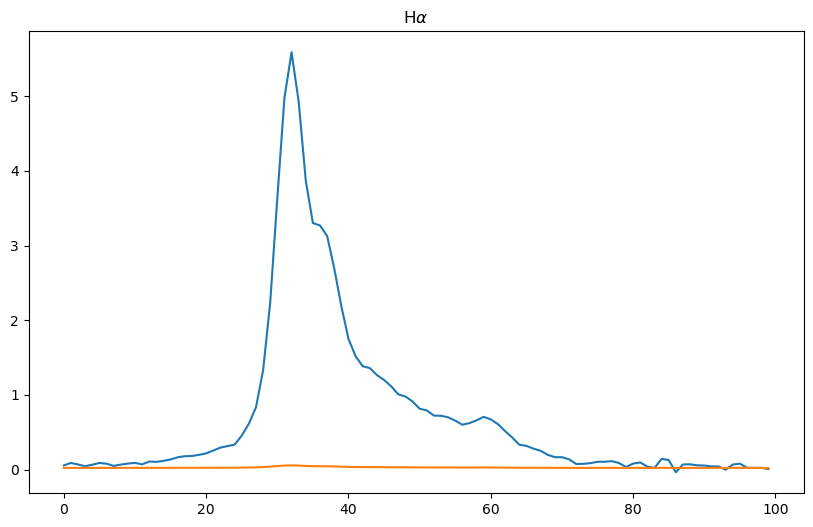

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Propagazione_errore/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 7)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 7)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (30, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 50),

     (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 15247.189857183268
differential_evolution step 2: f(x)= 15247.189857183268
differential_evolution step 3: f(x)= 6283.311542285972
differential_evolution step 4: f(x)= 3287.7786492242726
differential_evolution step 5: f(x)= 3287.7786492242726
differential_evolution step 6: f(x)= 3287.7786492242726
differential_evolution step 7: f(x)= 1046.7554670529607
differential_evolution step 8: f(x)= 1046.7554670529607
differential_evolution step 9: f(x)= 1046.7554670529607
differential_evolution step 10: f(x)= 989.55537320738
differential_evolution step 11: f(x)= 989.55537320738
differential_evolution step 12: f(x)= 921.6020633696328
differential_evolution step 13: f(x)= 517.7883806043668
differential_evolution step 14: f(x)= 517.7883806043668
differential_evolution step 15: f(x)= 517.7883806043668
differential_evolution step 16: f(x)= 517.7883806043668
differential_evolution step 17: f(x)= 319.7629863748092
differential_evolution step 18: f(x)= 141.27291108456

Sérsic 1: I_e=0.1146, r_e=14.7618, n=3.0723, x_0=31.7055
Sérsic 2: I_e=0.5969, r_e=3.8172, n=0.9552, x_0=36.5158
Sérsic 3: I_e=0.3626, r_e=8.4998, n=0.5950, x_0=45.0399
Sérsic 4: I_e=0.0288, r_e=34.9840, n=1.8785, x_0=59.5719


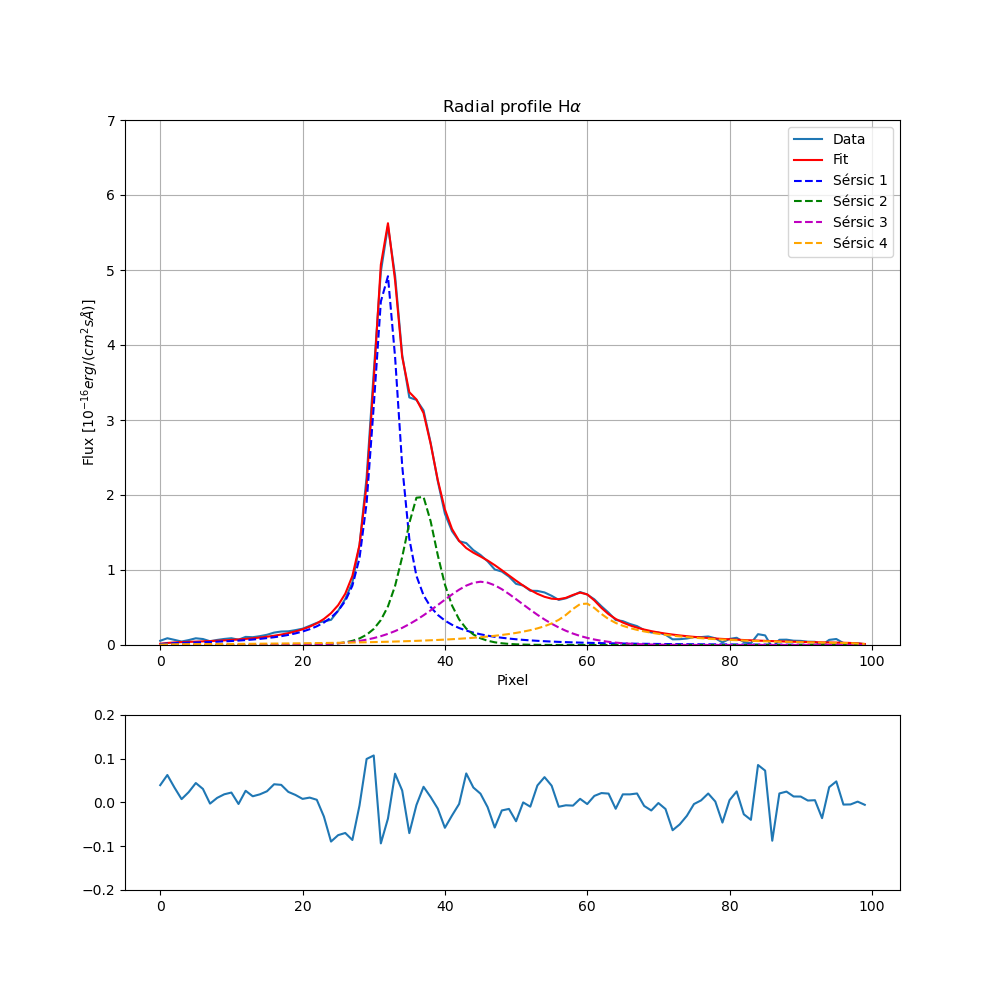

In [13]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
print(result.x)

[1.14631869e-01 1.47618280e+01 3.07228643e+00 3.17054749e+01
 5.96851398e-01 3.81724513e+00 9.55241498e-01 3.65158389e+01
 3.62632960e-01 8.49978156e+00 5.94994509e-01 4.50399468e+01
 2.88402435e-02 3.49840327e+01 1.87852757e+00 5.95719461e+01]


In [17]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 32),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 10),
    (0.1, 10),
    (34, 38),

    (0, 1),
    (0, 10),
    (0.1, 10),
    (45, 50),

     (0, 1),
    (0, 50),
    (0.1, 10),
    (57, 61)
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0375, r_e=28.7301, n=4.0708, x_0=31.6212
Sérsic 2: I_e=0.6959, r_e=3.7661, n=0.8668, x_0=36.2909
Sérsic 3: I_e=0.3536, r_e=9.0860, n=0.6103, x_0=45.0000
Sérsic 4: I_e=0.0216, r_e=39.9560, n=2.0523, x_0=59.6844
[4.39223161e-02 2.03659769e+01 1.02301279e+00 6.22902279e-02
 3.28963249e-01 2.41518234e+00 3.70287445e-01 1.83561500e-01
 1.60743036e-01 2.40018947e+00 1.88574310e-01 2.47326655e+00
 2.36115938e-02 3.15707037e+01 6.16870068e-01 2.41102405e-01]
0.3394208978670101


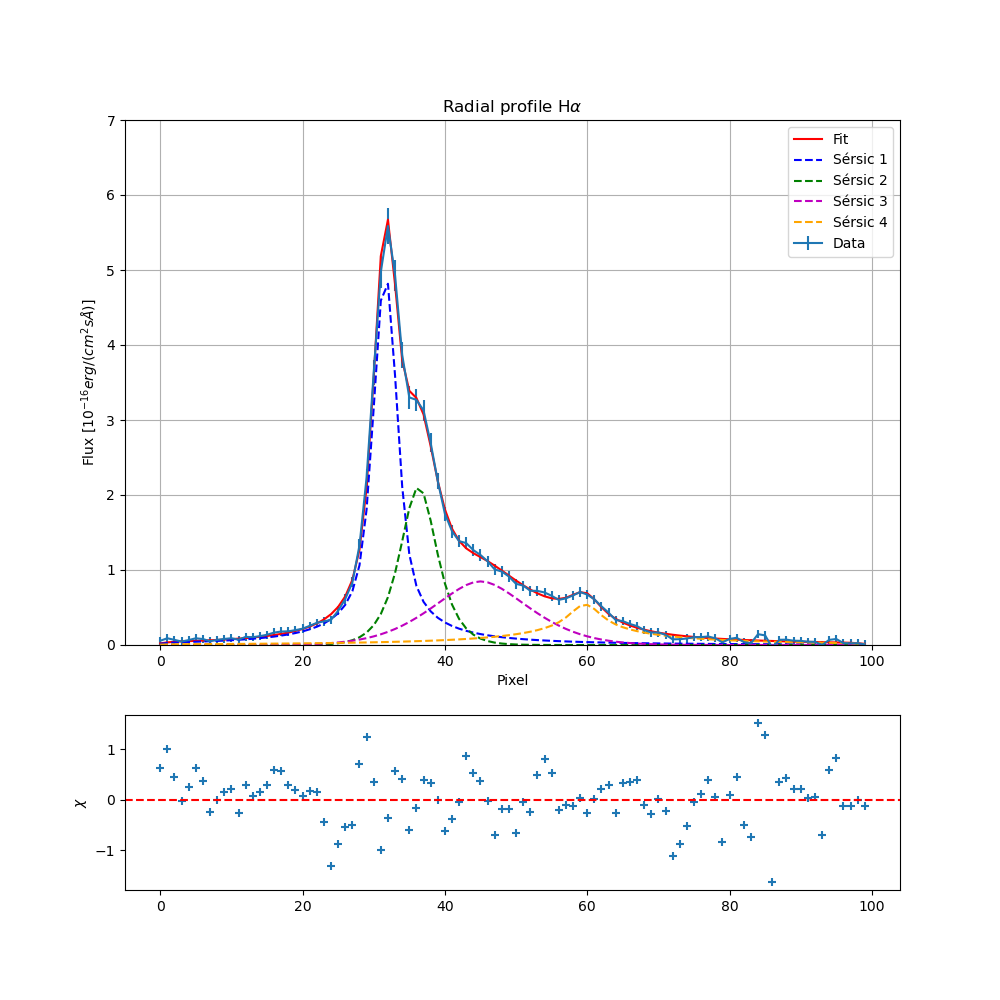

In [18]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [19]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

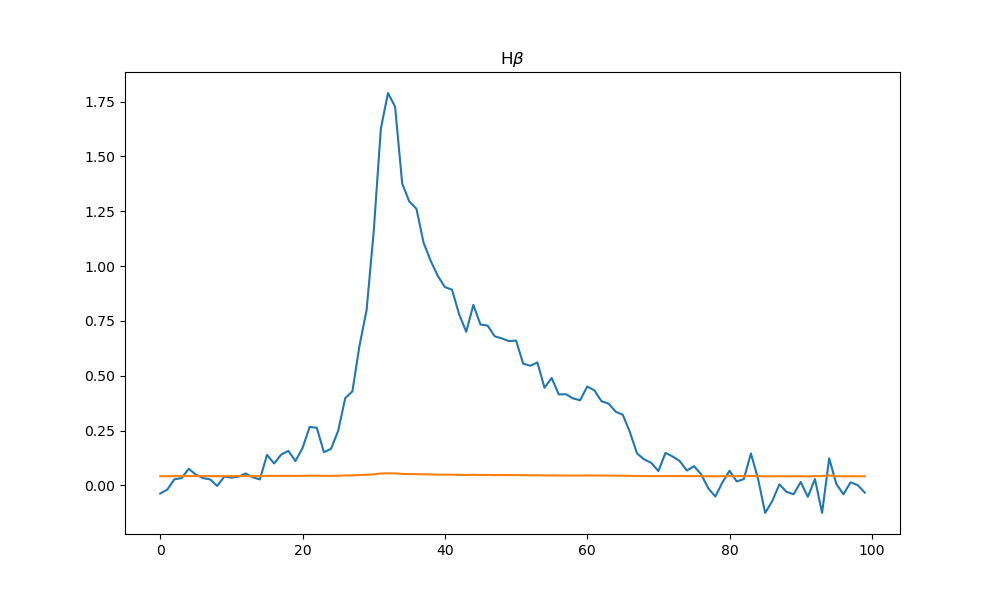

In [20]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[0])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [21]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 175.43539780530122
differential_evolution step 2: f(x)= 175.43539780530122
differential_evolution step 3: f(x)= 175.43539780530122
differential_evolution step 4: f(x)= 28.995265941918696
differential_evolution step 5: f(x)= 10.715472296586979
differential_evolution step 6: f(x)= 10.715472296586979
differential_evolution step 7: f(x)= 10.715472296586979
differential_evolution step 8: f(x)= 5.52367365458481
differential_evolution step 9: f(x)= 5.52367365458481
differential_evolution step 10: f(x)= 5.52367365458481
differential_evolution step 11: f(x)= 5.52367365458481
differential_evolution step 12: f(x)= 3.615187334188141
differential_evolution step 13: f(x)= 3.615187334188141
differential_evolution step 14: f(x)= 2.229376932524854
differential_evolution step 15: f(x)= 2.229376932524854
differential_evolution step 16: f(x)= 2.229376932524854
differential_evolution step 17: f(x)= 2.229376932524854
differential_evolution step 18: f(x)= 2.22937693252485

Sérsic 1: I_e=0.0756, r_e=5.5593, n=2.6444, x_0=31.8117
Sérsic 2: I_e=0.1355, r_e=3.7966, n=1.0108, x_0=36.1690
Sérsic 3: I_e=0.2865, r_e=16.4599, n=0.6302, x_0=43.5000
Sérsic 4: I_e=0.0409, r_e=5.0816, n=1.0829, x_0=61.1844


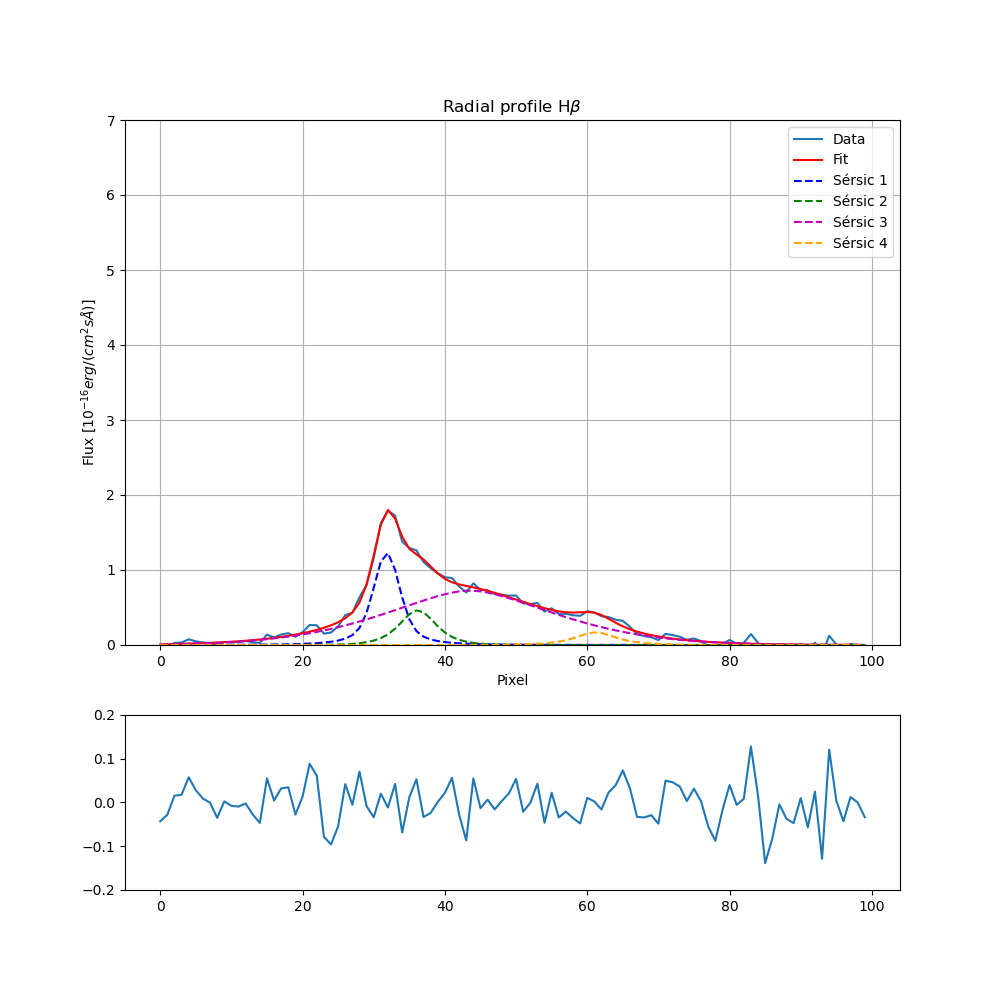

In [22]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [23]:
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3144\2126184941.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3144\2126184941.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3144\2126184941.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0920, r_e=4.6844, n=2.4956, x_0=31.8117
Sérsic 2: I_e=0.1484, r_e=3.7128, n=0.9217, x_0=36.1525
Sérsic 3: I_e=0.3070, r_e=16.3154, n=0.5913, x_0=43.5897
Sérsic 4: I_e=0.0902, r_e=3.2557, n=0.0545, x_0=62.3411
[1.37087378e+00 4.32555763e+01 2.22704986e+01 1.02703780e-02
 2.36999472e-01 5.44259918e+00 1.26540143e+00 4.94579754e-01
 1.06400669e-01 1.51969191e+00 9.66502259e-02 4.16100367e+00
 5.59215346e+00 2.08628559e+01 2.60631937e+00 5.47328245e-01]
0.2810528381074643


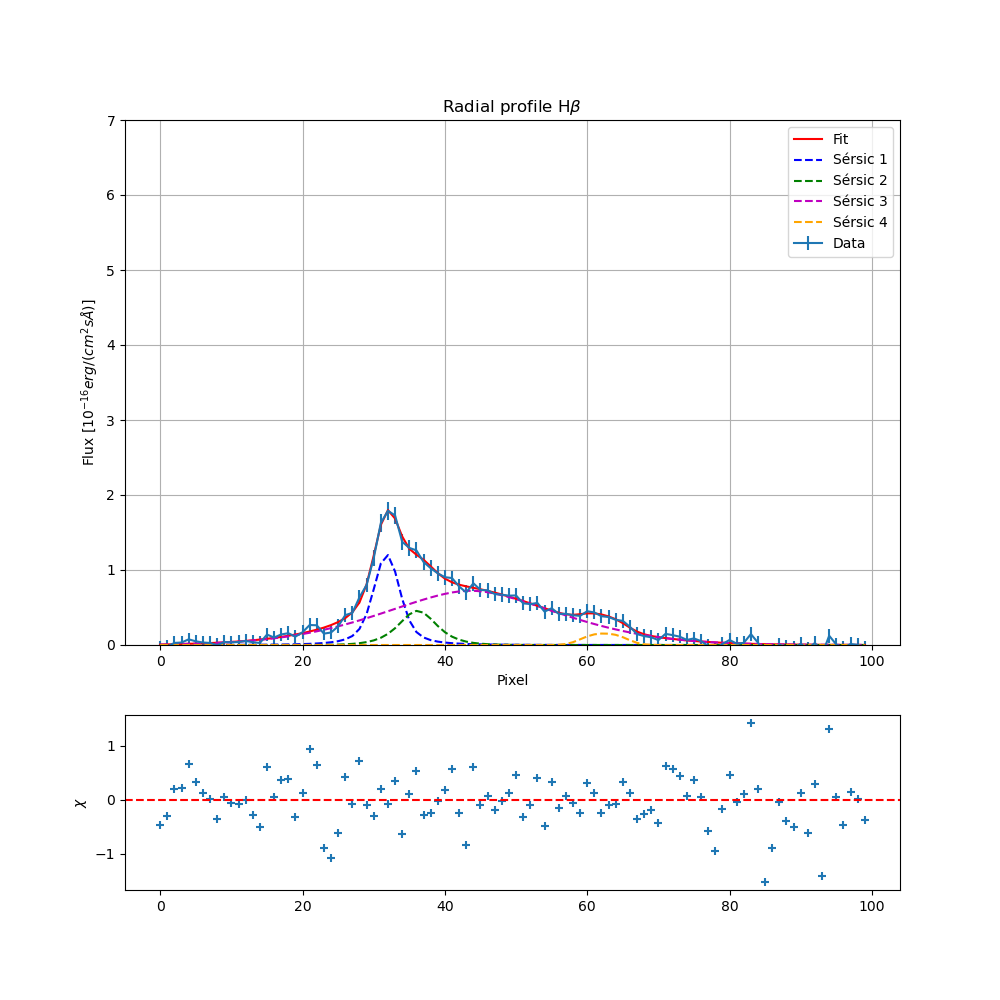

In [24]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

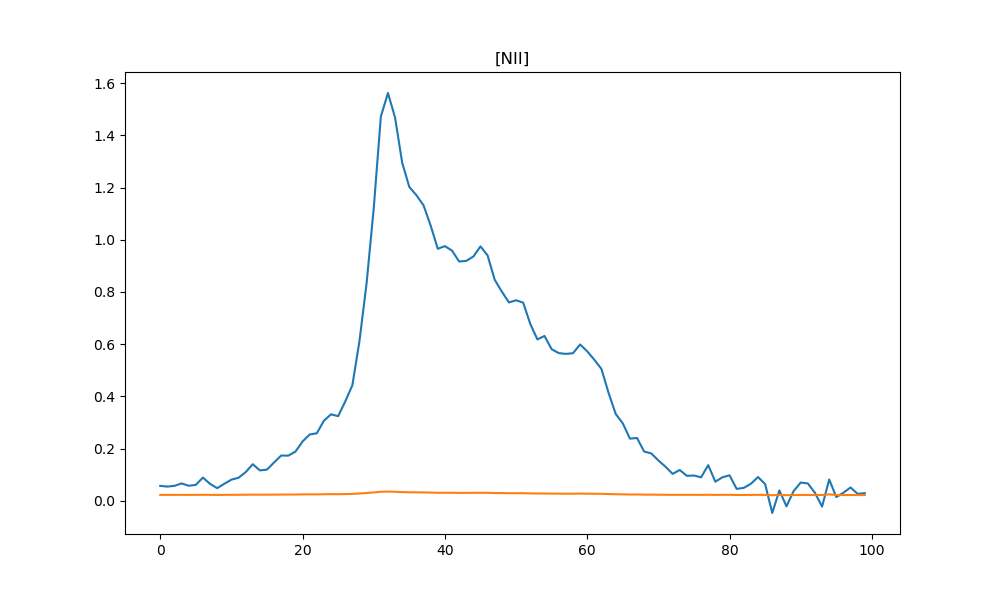

In [25]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [26]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 91.83248060039094
differential_evolution step 2: f(x)= 42.61855953134134
differential_evolution step 3: f(x)= 42.61855953134134
differential_evolution step 4: f(x)= 10.583479206392456
differential_evolution step 5: f(x)= 10.583479206392456
differential_evolution step 6: f(x)= 4.526961913150571
differential_evolution step 7: f(x)= 2.548661889553586
differential_evolution step 8: f(x)= 2.548661889553586
differential_evolution step 9: f(x)= 2.548661889553586
differential_evolution step 10: f(x)= 2.473979269316546
differential_evolution step 11: f(x)= 2.473979269316546
differential_evolution step 12: f(x)= 2.473979269316546
differential_evolution step 13: f(x)= 2.473979269316546
differential_evolution step 14: f(x)= 2.1484275010981526
differential_evolution step 15: f(x)= 1.978373042339937
differential_evolution step 16: f(x)= 1.8596930008158594
differential_evolution step 17: f(x)= 1.8596930008158594
differential_evolution step 18: f(x)= 0.894237677888

Sérsic 1: I_e=0.4615, r_e=1.7651, n=0.7518, x_0=31.6561
Sérsic 2: I_e=0.0280, r_e=45.8782, n=1.9846, x_0=36.1440
Sérsic 3: I_e=0.2351, r_e=16.3628, n=0.7242, x_0=45.4781
Sérsic 4: I_e=0.0636, r_e=4.3229, n=0.9685, x_0=60.2919


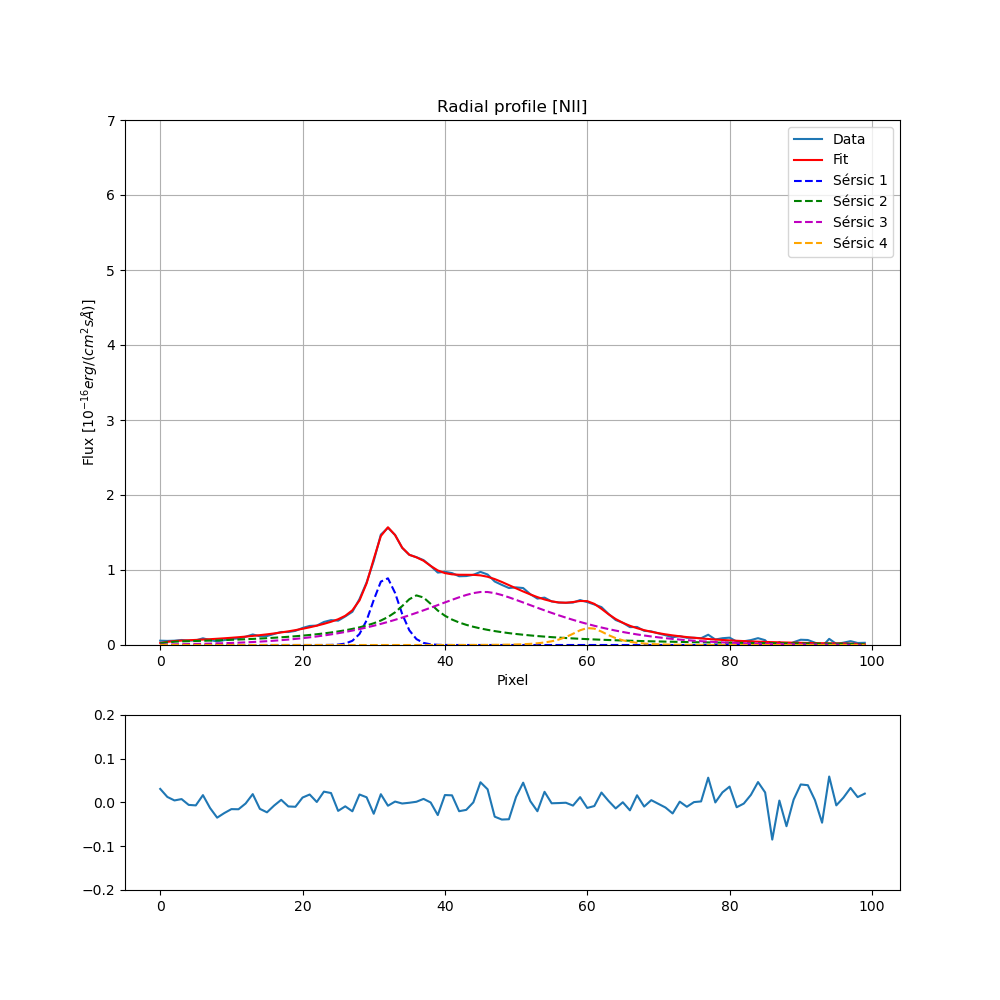

In [27]:
# Plots:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [28]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII) #, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5259, r_e=1.7335, n=0.6496, x_0=31.6884
Sérsic 2: I_e=0.0033, r_e=205.5612, n=3.2695, x_0=36.2183
Sérsic 3: I_e=0.2869, r_e=16.2470, n=0.6583, x_0=44.5851
Sérsic 4: I_e=0.0878, r_e=3.0087, n=0.7171, x_0=60.4012
[1.97799411e-01 2.72424304e-01 3.08997019e-01 6.76236952e-02
 1.40925806e-02 6.35344636e+02 2.90154120e+00 1.33812815e-03
 4.42758357e-02 9.42200544e-01 5.10673334e-02 9.95868870e-01
 5.51935906e-02 1.28121091e+00 4.86214216e-01 2.44895365e-01]
0.1824005556219543


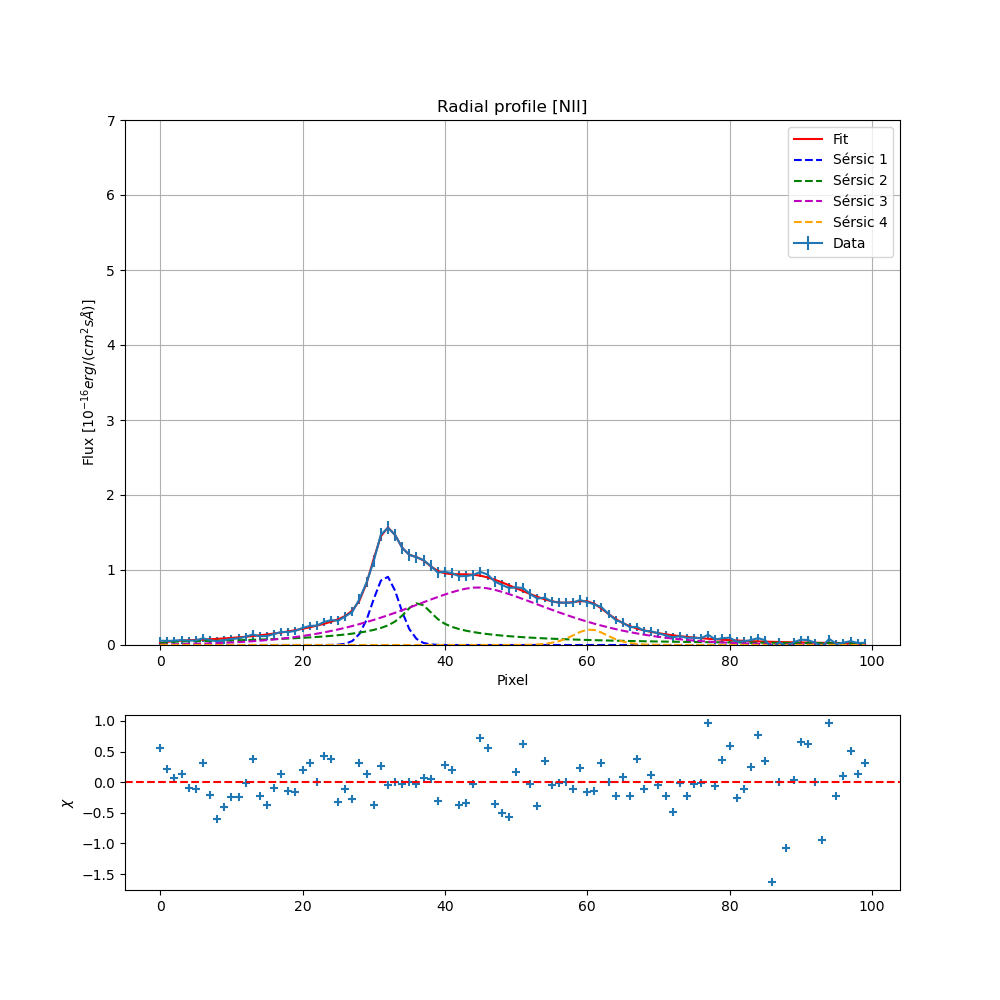

In [29]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

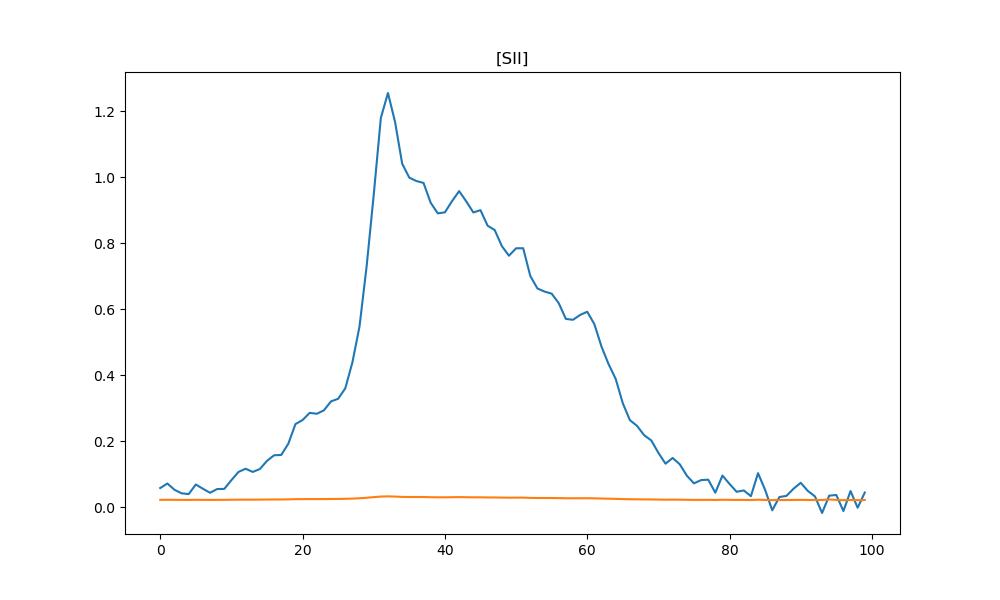

In [30]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[3])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [31]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 276.74324523742945
differential_evolution step 2: f(x)= 232.21972394131006
differential_evolution step 3: f(x)= 81.00403445046676
differential_evolution step 4: f(x)= 81.00403445046676
differential_evolution step 5: f(x)= 16.33522617591122
differential_evolution step 6: f(x)= 16.33522617591122
differential_evolution step 7: f(x)= 5.00213509913198
differential_evolution step 8: f(x)= 5.00213509913198
differential_evolution step 9: f(x)= 5.00213509913198
differential_evolution step 10: f(x)= 5.00213509913198
differential_evolution step 11: f(x)= 2.2866572796016067
differential_evolution step 12: f(x)= 1.799162189626927
differential_evolution step 13: f(x)= 1.584730544312462
differential_evolution step 14: f(x)= 1.584730544312462
differential_evolution step 15: f(x)= 1.584730544312462
differential_evolution step 16: f(x)= 1.584730544312462
differential_evolution step 17: f(x)= 1.584730544312462
differential_evolution step 18: f(x)= 1.584730544312462
di

Sérsic 1: I_e=0.3266, r_e=1.4032, n=0.7459, x_0=31.4727
Sérsic 2: I_e=0.1561, r_e=18.4561, n=0.9711, x_0=35.0244
Sérsic 3: I_e=0.2842, r_e=8.4942, n=0.4077, x_0=46.5000
Sérsic 4: I_e=0.0425, r_e=21.5987, n=1.4308, x_0=60.6667


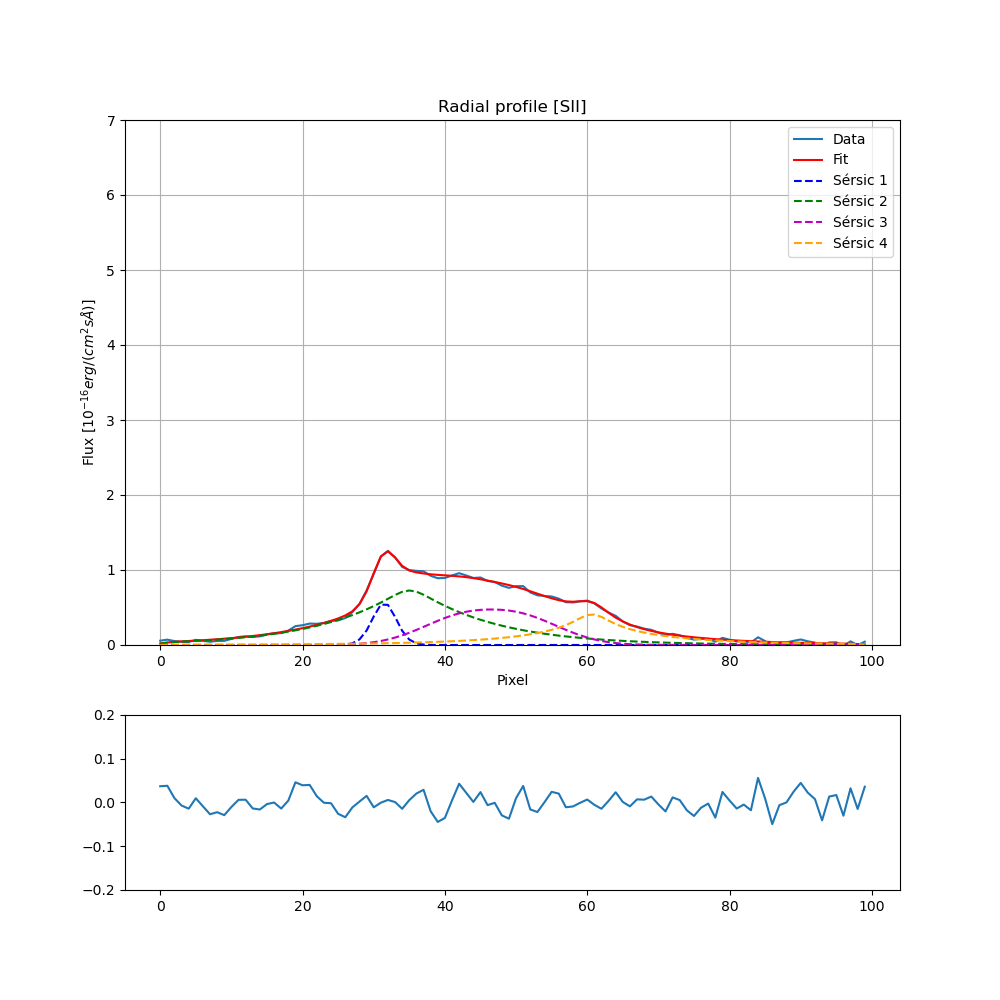

In [32]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [33]:
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.3828, r_e=1.4059, n=0.6100, x_0=31.5033
Sérsic 2: I_e=0.1655, r_e=18.2887, n=0.9798, x_0=35.4428
Sérsic 3: I_e=0.2814, r_e=7.7887, n=0.3822, x_0=47.1774
Sérsic 4: I_e=0.0422, r_e=21.1340, n=1.4551, x_0=60.7347
[0.32509818 0.56580085 0.72284447 0.18773755 0.02861961 1.32058623
 0.09186439 1.4912809  0.05964954 1.77967204 0.0905771  1.44928645
 0.01401124 5.0692408  0.19082299 0.34025109]
0.1679994856894399


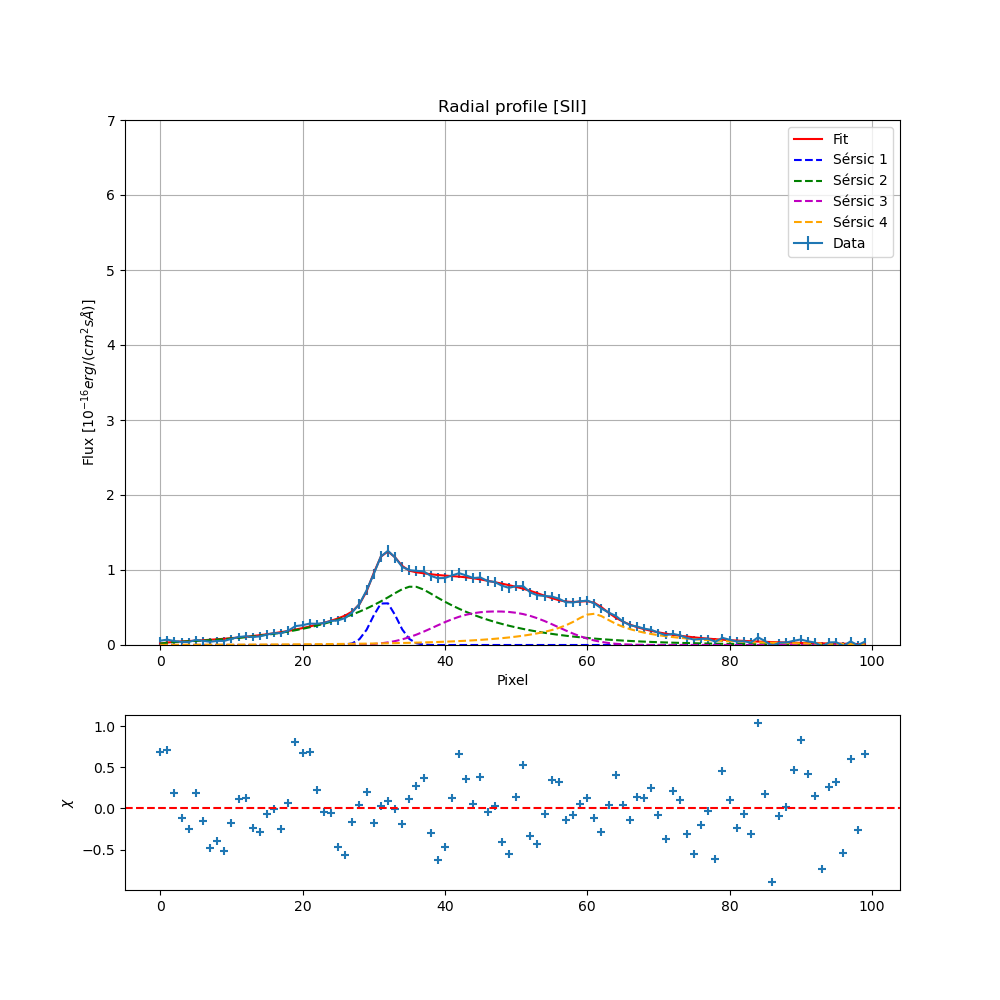

In [34]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

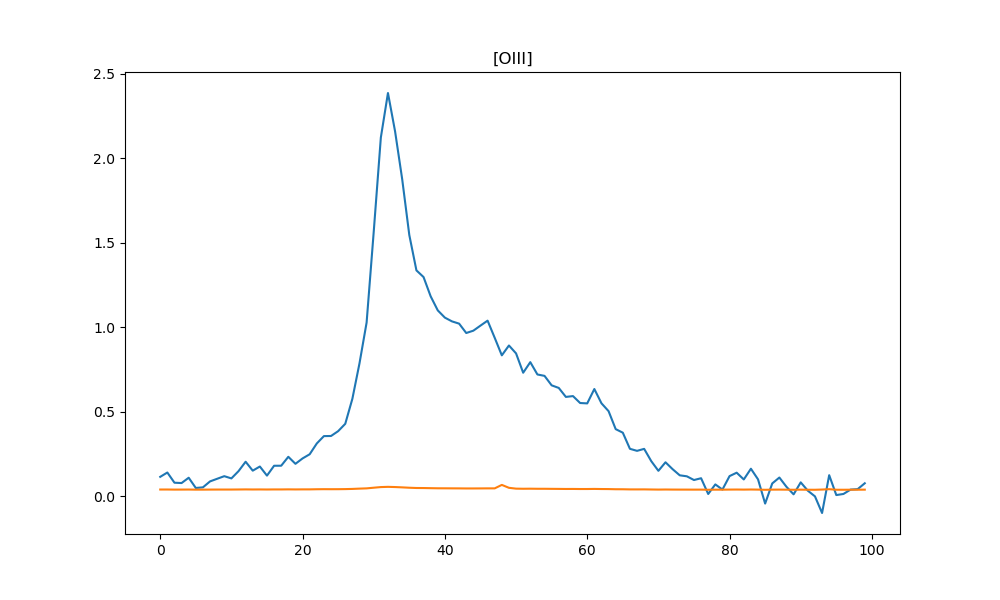

In [35]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[1])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [36]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 274.77900679026044
differential_evolution step 2: f(x)= 274.77900679026044
differential_evolution step 3: f(x)= 131.6098127312636
differential_evolution step 4: f(x)= 58.85719551528251
differential_evolution step 5: f(x)= 12.900247776898148
differential_evolution step 6: f(x)= 3.5039081643802197
differential_evolution step 7: f(x)= 3.5039081643802197
differential_evolution step 8: f(x)= 3.5039081643802197
differential_evolution step 9: f(x)= 3.5039081643802197
differential_evolution step 10: f(x)= 3.5039081643802197
differential_evolution step 11: f(x)= 3.5039081643802197
differential_evolution step 12: f(x)= 3.5039081643802197
differential_evolution step 13: f(x)= 3.0077260369100633
differential_evolution step 14: f(x)= 2.82990806945428
differential_evolution step 15: f(x)= 2.82990806945428
differential_evolution step 16: f(x)= 2.82990806945428
differential_evolution step 17: f(x)= 2.82990806945428
differential_evolution step 18: f(x)= 2.6227819339

Sérsic 1: I_e=0.3239, r_e=2.5826, n=1.6848, x_0=31.8677
Sérsic 2: I_e=0.0487, r_e=46.4359, n=1.7464, x_0=35.8803
Sérsic 3: I_e=0.2693, r_e=11.7435, n=0.5845, x_0=46.0246
Sérsic 4: I_e=0.0266, r_e=16.4768, n=1.5881, x_0=61.1844


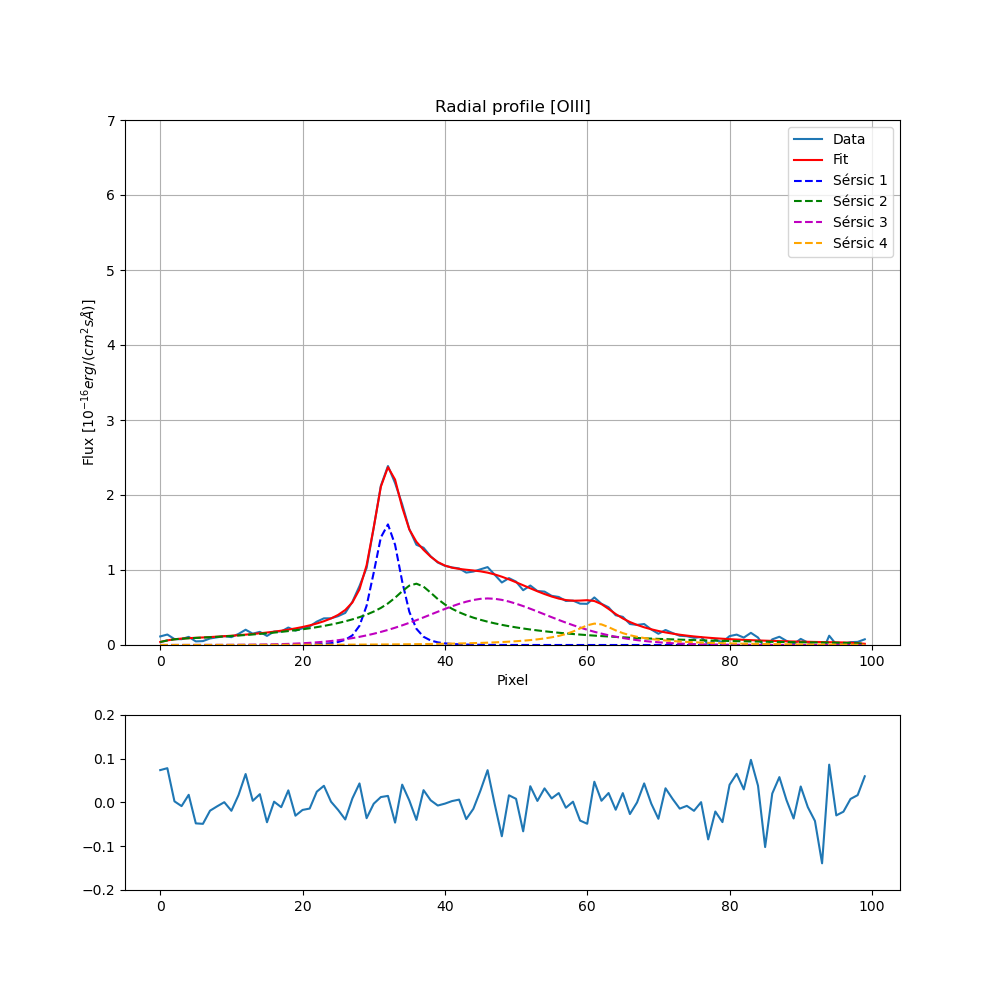

In [37]:
# Plots:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [38]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.3555, r_e=2.4928, n=1.5943, x_0=31.8897
Sérsic 2: I_e=0.0415, r_e=52.2385, n=1.8093, x_0=36.0059
Sérsic 3: I_e=0.2831, r_e=12.3748, n=0.5711, x_0=46.1038
Sérsic 4: I_e=0.0159, r_e=18.1067, n=1.9204, x_0=61.5934
[5.28337266e-01 2.16357746e+00 1.27933949e+00 1.31276295e-01
 9.29843276e-02 8.32095493e+01 1.17616382e+00 1.08891914e+00
 5.84402015e-02 6.71797623e+00 1.30752070e-01 1.78033977e+00
 6.88086685e-02 5.67292100e+01 3.82861135e+00 1.75888921e-01]
0.2621596120337461


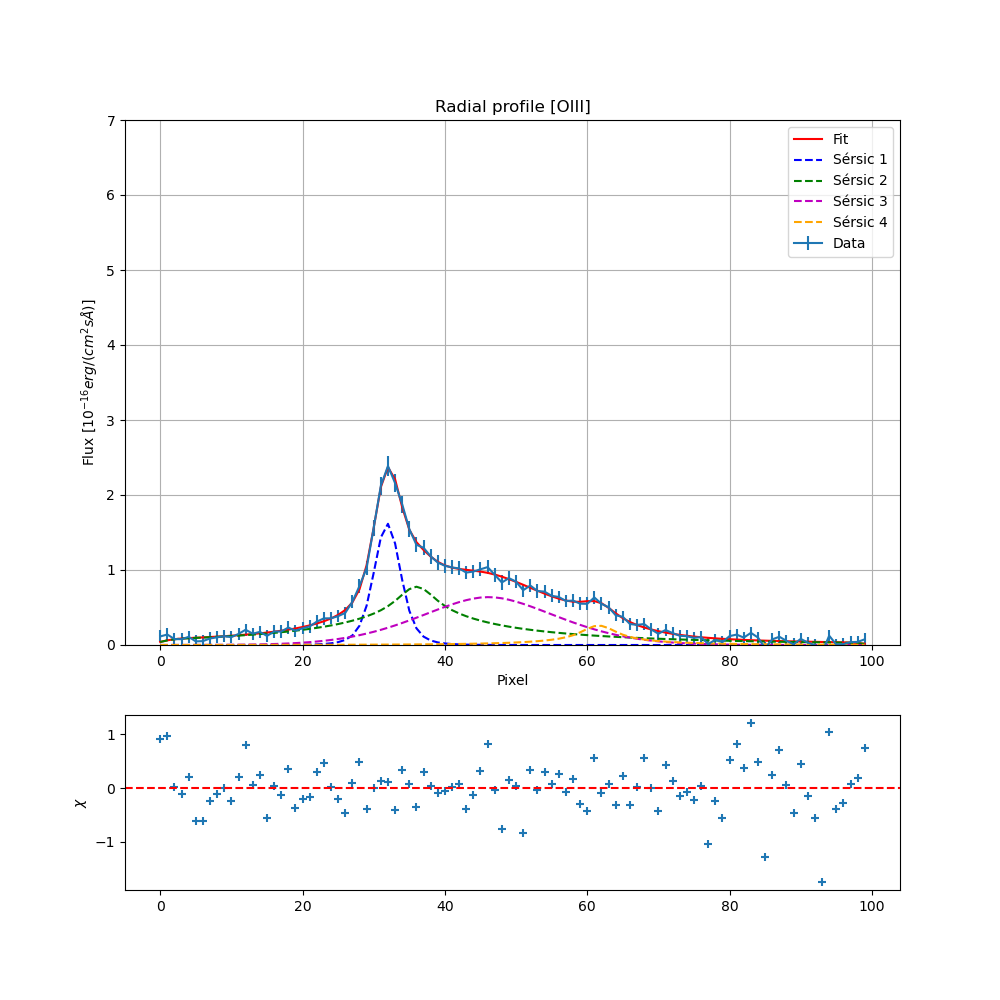

In [39]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [40]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

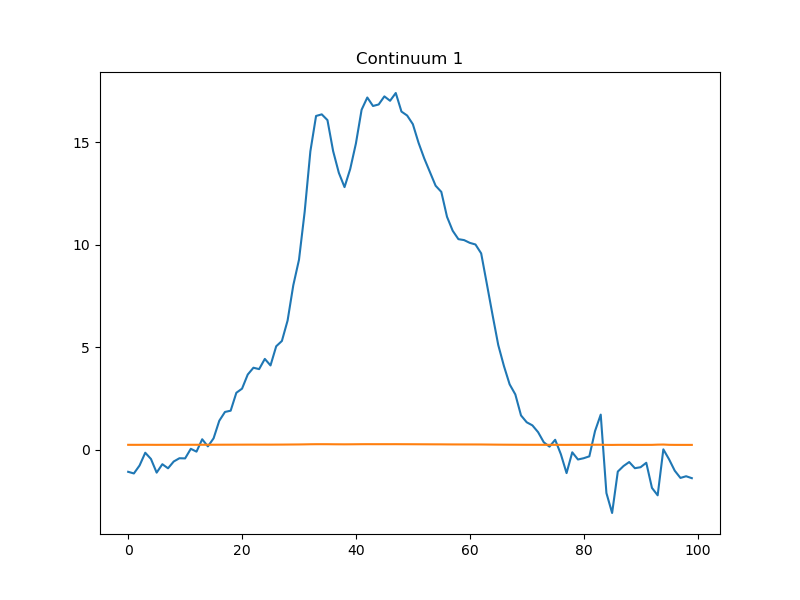

In [41]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[0])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [42]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3237.3608530302927
differential_evolution step 2: f(x)= 3237.3608530302927
differential_evolution step 3: f(x)= 3237.3608530302927
differential_evolution step 4: f(x)= 2347.601588972347
differential_evolution step 5: f(x)= 2020.7407541945222
differential_evolution step 6: f(x)= 1385.989147427083
differential_evolution step 7: f(x)= 1385.989147427083
differential_evolution step 8: f(x)= 1113.882030848135
differential_evolution step 9: f(x)= 1113.882030848135
differential_evolution step 10: f(x)= 1113.882030848135
differential_evolution step 11: f(x)= 1113.882030848135
differential_evolution step 12: f(x)= 1113.882030848135
differential_evolution step 13: f(x)= 1113.882030848135
differential_evolution step 14: f(x)= 776.4994617229916
differential_evolution step 15: f(x)= 776.4994617229916
differential_evolution step 16: f(x)= 776.4994617229916
differential_evolution step 17: f(x)= 776.4994617229916
differential_evolution step 18: f(x)= 776.49946172299

In [43]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)    

Sérsic 1: I_e=7.3006, r_e=2.0203, n=0.1012, x_0=33.1172
Sérsic 2: I_e=3.0984, r_e=17.0536, n=0.1000, x_0=37.2883
Sérsic 3: I_e=6.7093, r_e=10.5345, n=0.5192, x_0=45.3262
Sérsic 4: I_e=2.2964, r_e=5.3178, n=0.8036, x_0=61.4698


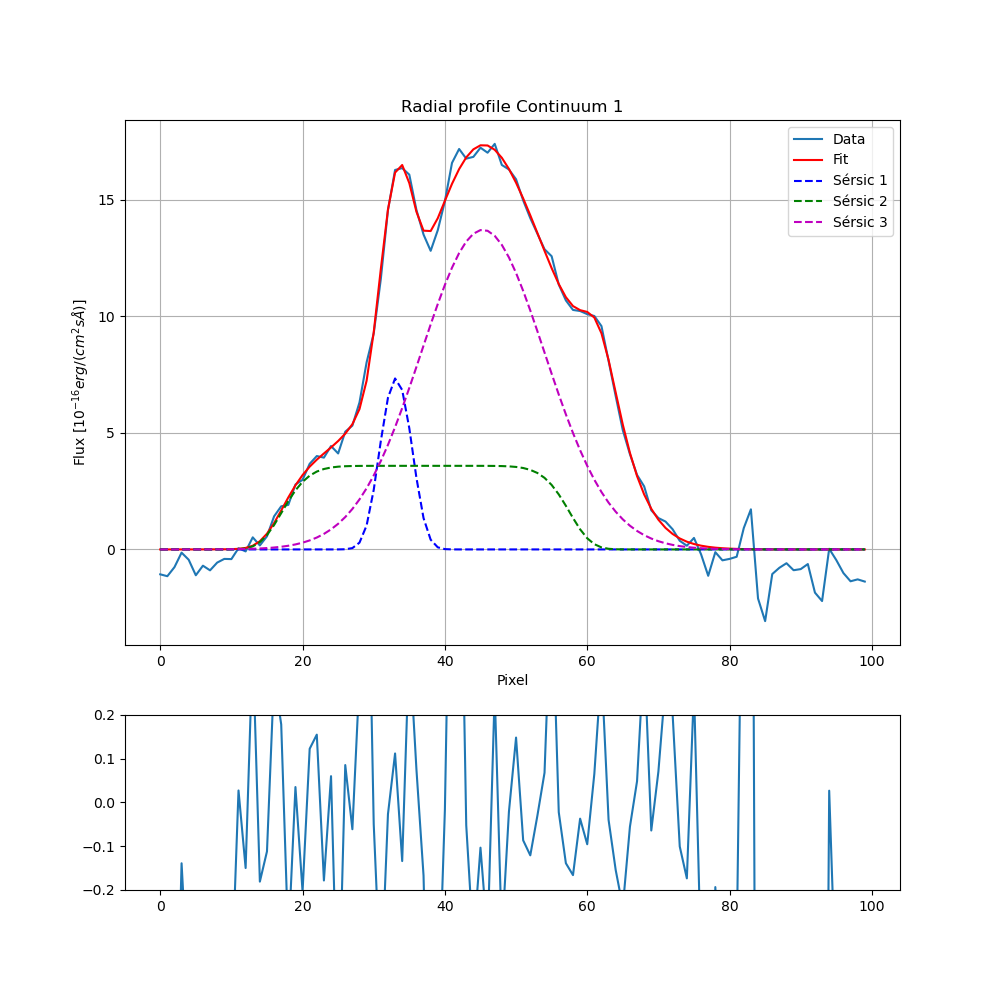

In [44]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [45]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=4.5809, r_e=2.1011, n=0.6042, x_0=33.0897
Sérsic 2: I_e=3.3979, r_e=16.0800, n=0.1119, x_0=36.9985
Sérsic 3: I_e=6.7208, r_e=9.8612, n=0.5091, x_0=45.4869
Sérsic 4: I_e=2.7342, r_e=5.3860, n=0.7156, x_0=61.2662
[10.18305972  3.20636124  1.9458097   0.44310974  4.42669762  7.18771326
  0.14165274  6.32887907  1.88986468 10.03654307  0.32501508  0.9758759
  2.29395159  2.37889267  0.42135599  2.11825713]
7.718842145347712


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3144\2895385259.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


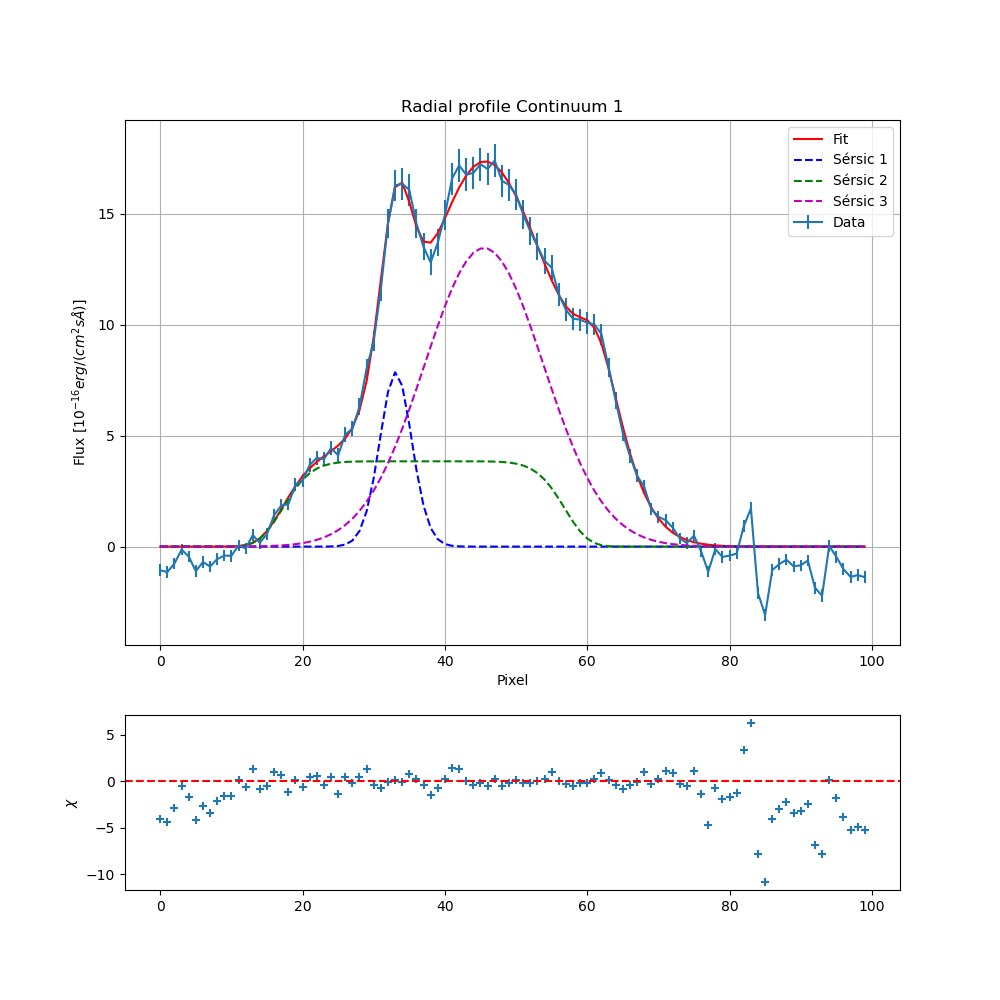

In [46]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

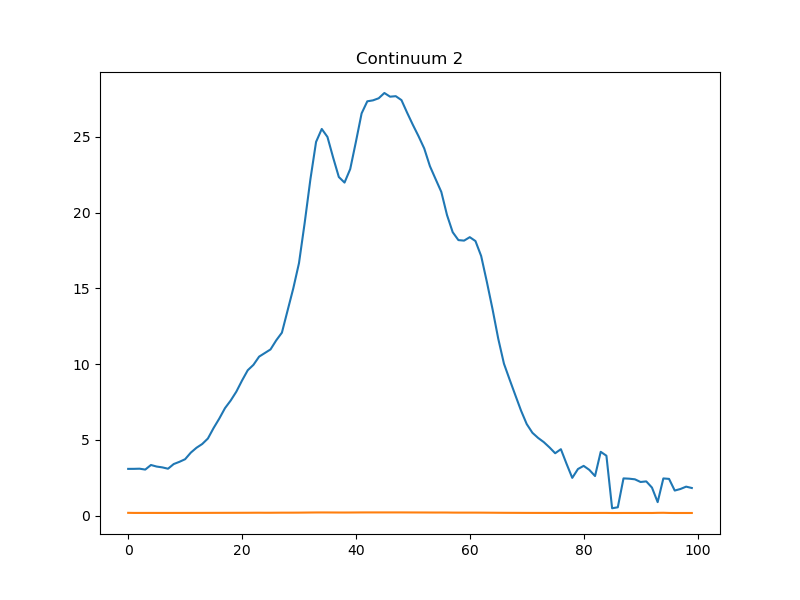

In [47]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [48]:
# Bounds:
bounds = bounds_HA
seeing_i = 3.174
sigma_i = seeing_i/ 2.35

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigma_i)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4302.126180011247
differential_evolution step 2: f(x)= 4302.126180011247
differential_evolution step 3: f(x)= 3200.94715791074
differential_evolution step 4: f(x)= 3200.94715791074
differential_evolution step 5: f(x)= 1334.4203924471626
differential_evolution step 6: f(x)= 1334.4203924471626
differential_evolution step 7: f(x)= 1334.4203924471626
differential_evolution step 8: f(x)= 1334.4203924471626
differential_evolution step 9: f(x)= 1334.4203924471626
differential_evolution step 10: f(x)= 1275.273794475323
differential_evolution step 11: f(x)= 1275.273794475323
differential_evolution step 12: f(x)= 1234.3357098542103
differential_evolution step 13: f(x)= 1153.8963663058603
differential_evolution step 14: f(x)= 839.1437366464085
differential_evolution step 15: f(x)= 839.1437366464085
differential_evolution step 16: f(x)= 619.3944102901428
differential_evolution step 17: f(x)= 316.3226121609858
differential_evolution step 18: f(x)= 316.3226121609

Sérsic 1: I_e=6.7091, r_e=1.6339, n=0.1017, x_0=33.2985
Sérsic 2: I_e=1.7918, r_e=50.0000, n=0.8549, x_0=33.9176
Sérsic 3: I_e=9.2340, r_e=15.6115, n=0.6089, x_0=46.3722
Sérsic 4: I_e=2.1147, r_e=2.4350, n=0.6853, x_0=61.6196


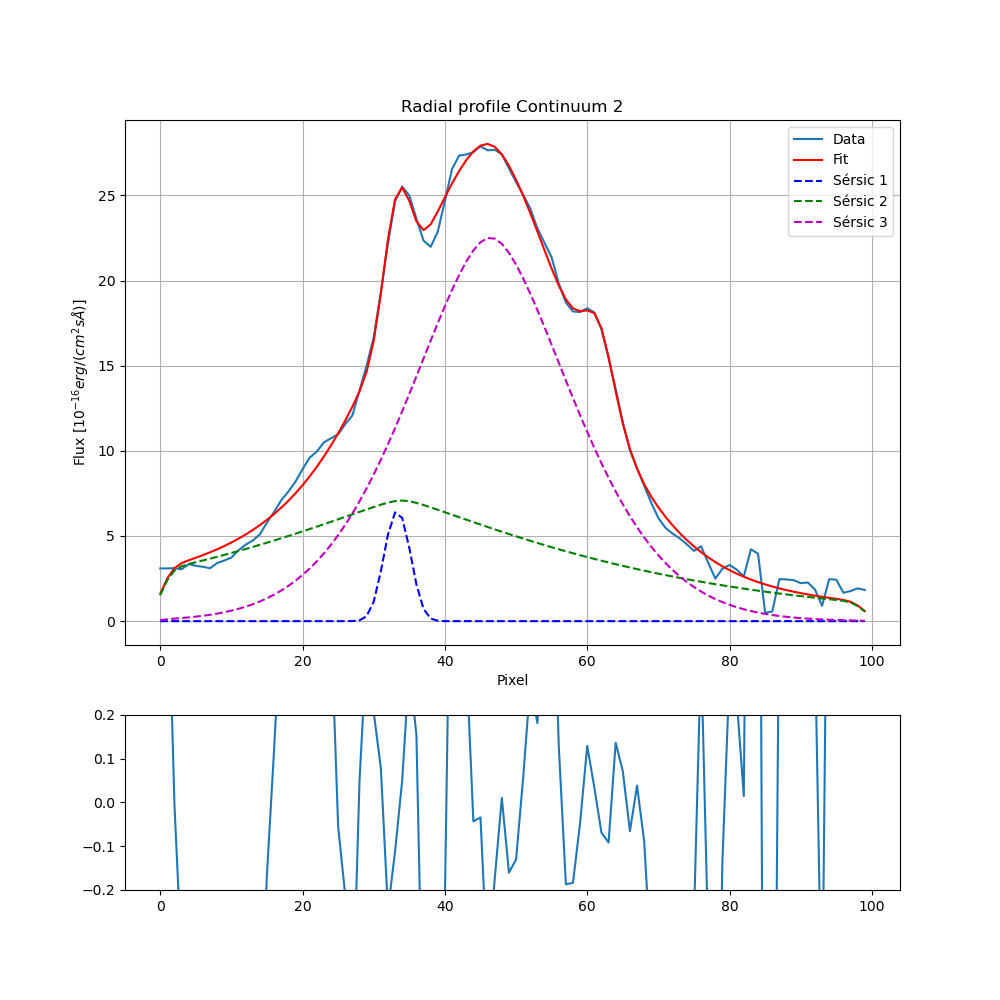

In [49]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigma_i,
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [50]:
bounds = bounds_HA
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigma_i, *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigma_i, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=7.6868, r_e=1.0750, n=0.1000, x_0=33.2130
Sérsic 2: I_e=1.9800, r_e=50.0000, n=0.7841, x_0=38.1397
Sérsic 3: I_e=10.0000, r_e=14.8440, n=0.5303, x_0=45.0000
Sérsic 4: I_e=2.1715, r_e=3.0338, n=0.6712, x_0=61.5352
[9.71329265e+02 1.67520637e+02 4.31481778e+01 5.85988549e-01
 1.96676761e+00 3.32235003e+01 7.70346682e-01 6.00228776e+00
 2.33506522e+00 1.95138922e+00 1.03462442e-01 2.02967658e+00
 2.84219047e+00 2.81924514e+00 1.05940090e+00 7.40880660e-01]
6.477198321437212


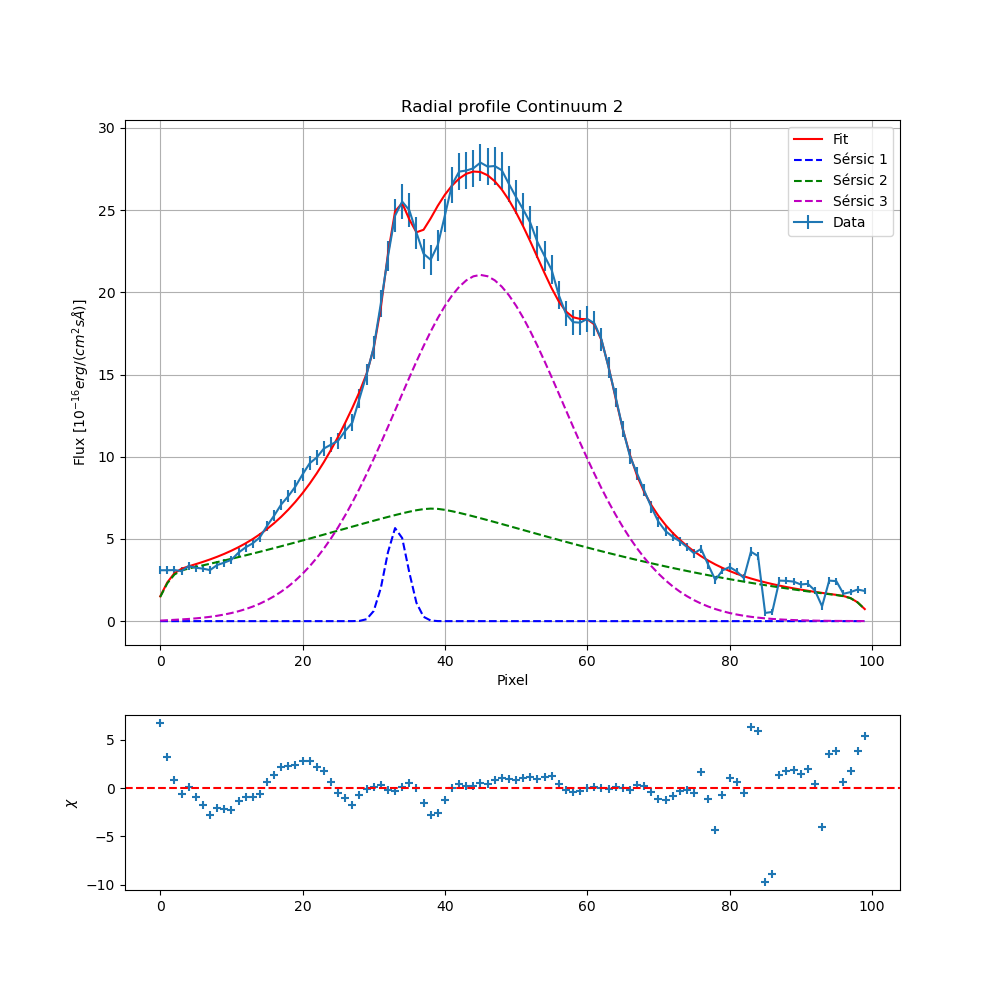

In [51]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigma_i, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

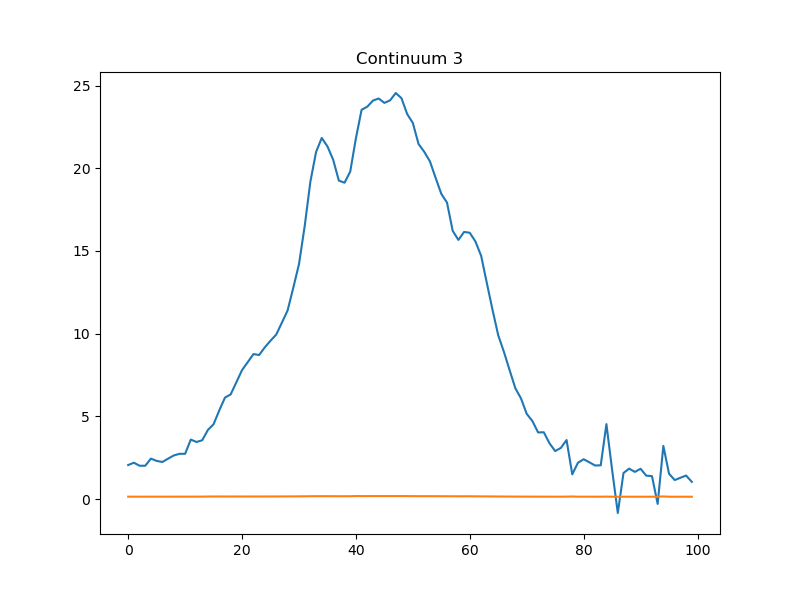

In [52]:
mask_continuum_3 = (wv > 6000)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [53]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 8278.616247914877
differential_evolution step 2: f(x)= 5253.5558568141805
differential_evolution step 3: f(x)= 4165.850012822918
differential_evolution step 4: f(x)= 4165.850012822918
differential_evolution step 5: f(x)= 3137.9376190220587
differential_evolution step 6: f(x)= 2082.981121116882
differential_evolution step 7: f(x)= 1378.7613041477512
differential_evolution step 8: f(x)= 1124.7241614973777
differential_evolution step 9: f(x)= 794.361901977191
differential_evolution step 10: f(x)= 794.361901977191
differential_evolution step 11: f(x)= 337.8211706435326
differential_evolution step 12: f(x)= 337.8211706435326
differential_evolution step 13: f(x)= 337.8211706435326
differential_evolution step 14: f(x)= 336.91013442735215
differential_evolution step 15: f(x)= 336.91013442735215
differential_evolution step 16: f(x)= 251.34910387473911
differential_evolution step 17: f(x)= 251.34910387473911
differential_evolution step 18: f(x)= 251.349103874

Sérsic 1: I_e=1.1474, r_e=50.0000, n=0.9678, x_0=31.9558
Sérsic 2: I_e=5.5571, r_e=1.5150, n=0.1000, x_0=33.4160
Sérsic 3: I_e=8.2607, r_e=16.1336, n=0.6290, x_0=46.3384
Sérsic 4: I_e=1.2544, r_e=3.4343, n=0.9189, x_0=61.3742


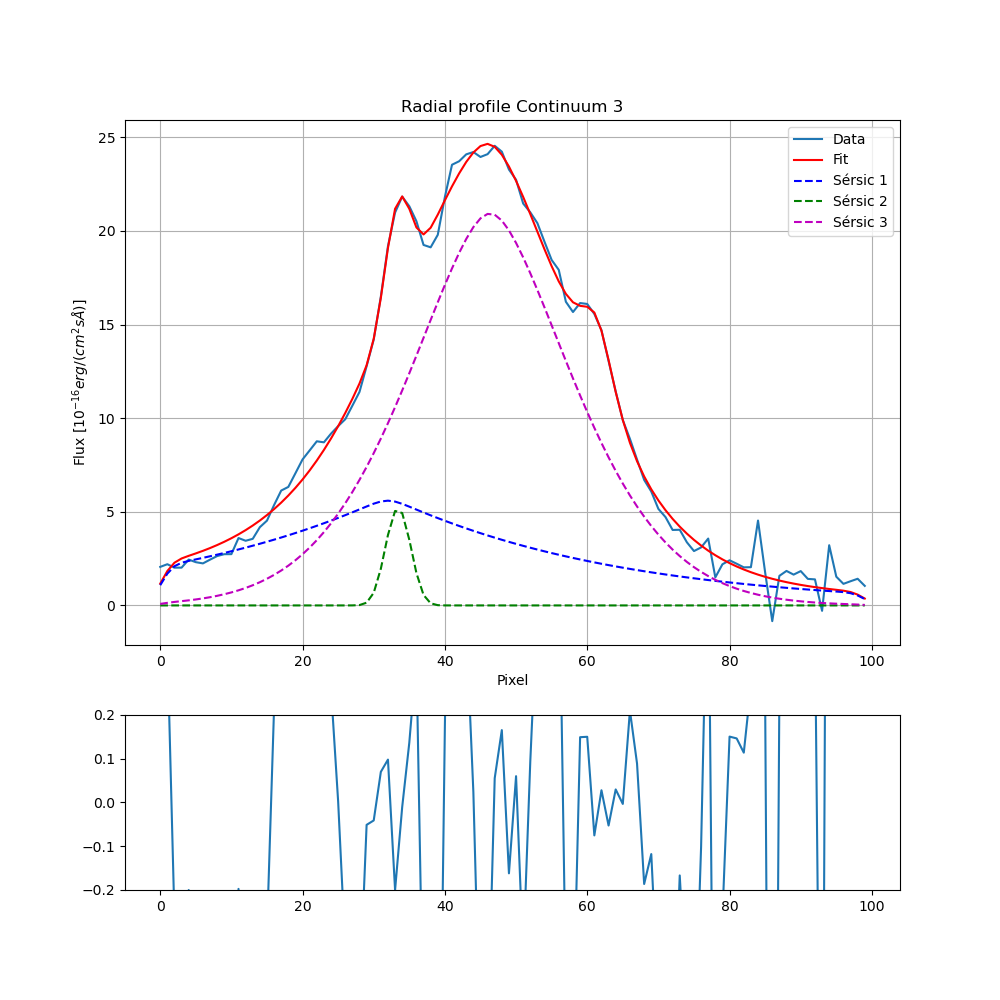

In [54]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [55]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3144\2126184941.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3144\2126184941.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1561, r_e=399.1337, n=1.7848, x_0=21.3646
Sérsic 2: I_e=3.6445, r_e=1.5382, n=0.0529, x_0=33.2387
Sérsic 3: I_e=10.4480, r_e=15.6676, n=0.5280, x_0=45.3027
Sérsic 4: I_e=1.3705, r_e=3.0116, n=0.7935, x_0=61.6491
[4.33353244e-01 1.03015235e+03 1.80186603e+00 1.67992812e+00
 3.54258336e+03 1.40675874e+02 3.72530542e+01 6.61898652e-01
 1.08767901e+00 7.32008205e-01 7.23573373e-02 1.05924739e+00
 3.10868334e+00 4.87522664e+00 1.83504554e+00 9.79859452e-01]
9.453829243442883


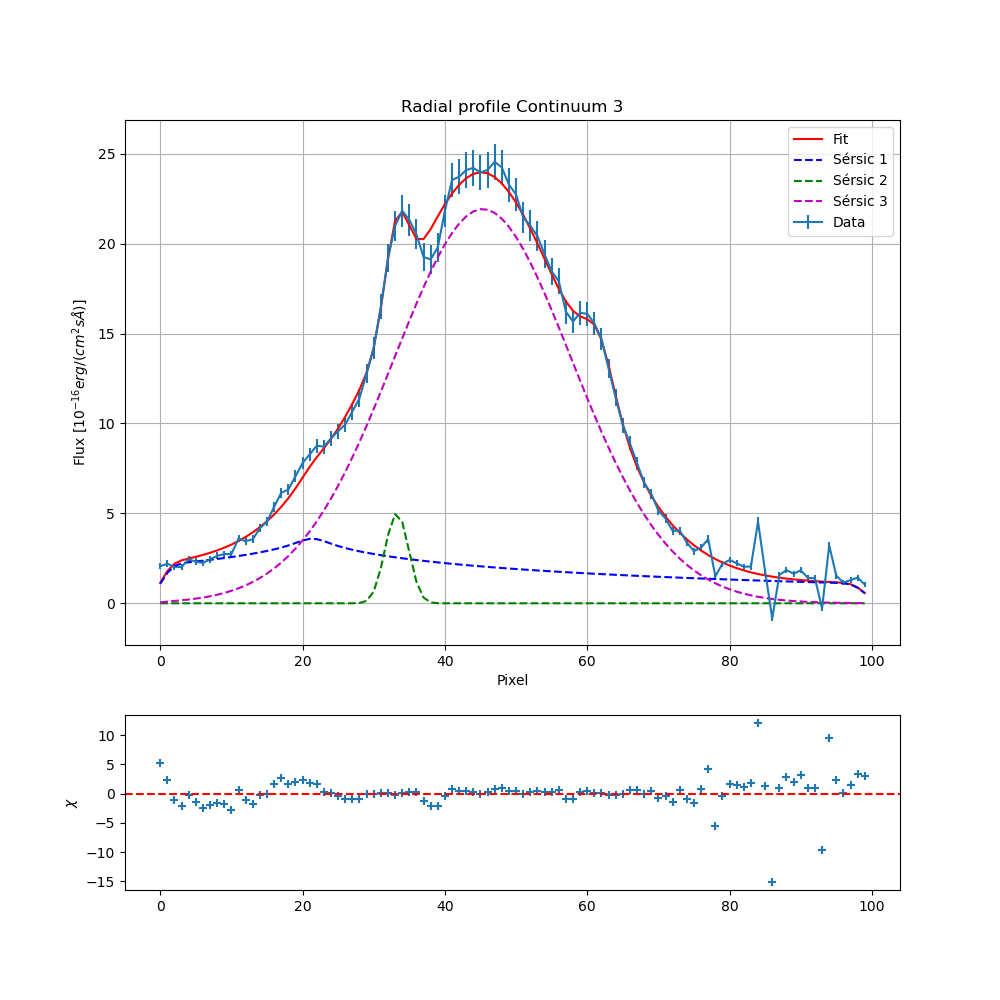

In [56]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

In [57]:
d1 = {'Name': ['Continuum 3'], 'Chi squared': chi2_continuum_3,
      'Dof': dof_continuum_3, 'Chi reduced': chi2_reduced_continuum_3}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_continuum_3.csv", index= False)

## Chi squared save

In [58]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

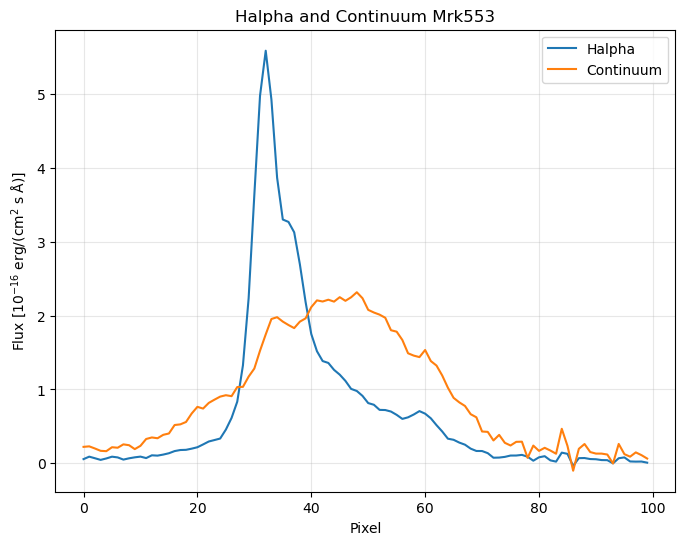

In [10]:
mask_continuum_3 = (wv > 6450)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum Mrk553')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_Mrk553')